Synthesize Criteo data using sequential CART models. (Note that this file uses the updated synthesis and optimization functions from the `helper_functions.py` file.).

In [1]:
import matplotlib.pyplot as plt
import sys

# Add the parent directory to path
sys.path.append('..')

# Then import
from helper_functions import *

rng = np.random.RandomState(42)

Import Criteo data (small version for testing)

In [2]:
train_data = pd.read_csv("../../Data/Criteo/cleaned_criteo_train_os.gz",
                         compression='gzip', 
                         sep='\,',
                         header=0,
                         engine='python')
                         
data_set = "train_os"

View confidential data to synthesize.

In [3]:
train_data

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,24.352730,10.059654,9.002550,4.679882,10.280525,4.115453,-9.404879,4.833815,3.892853,13.190056,5.300375,-0.168679,1,0,0,0
1,20.027816,10.059654,8.653796,3.359763,14.339694,4.115453,-9.864621,4.833815,3.781017,35.805995,5.916066,-0.473542,0,1,1,0
2,21.787905,10.059654,8.440707,4.679882,10.280525,4.115453,-8.493011,4.833815,3.842828,29.214161,5.300375,-0.168679,1,0,0,0
3,13.954588,10.059654,8.214851,-1.072603,10.280525,4.115453,-11.495164,4.833815,3.863287,33.213193,5.300375,-0.168679,1,1,1,1
4,23.970150,10.059654,8.214383,4.679882,10.280525,3.013064,-11.398781,10.591158,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,24.941363,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61157,23.106934,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
61158,25.975578,10.059654,8.475106,4.679882,11.561050,4.115453,-2.411115,4.833815,3.835851,23.570168,6.034478,-0.168679,1,1,1,0
61159,23.131460,10.059654,8.634955,4.679882,10.280525,4.115453,-5.576414,4.833815,3.880455,16.226044,5.300375,-0.168679,1,1,1,0


How many control group observations do we have?

In [4]:
np.mean(train_data.treatment == 0) * train_data.shape[0]

np.float64(7676.0)

Set up dictionary of parameter bounds for the Bayesian optimization process. The current state of the code requires a set of bounds for each parameter being optimized.

In [5]:
# define some default bounds for leaf values. These will be appropriately filled in during the loop below

param_bounds = {
    'tree': {
        'f0': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f1': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f2': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f3': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f4': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f5': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f6': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        },
        'f7': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f8': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [4063, 10000]  # [min, max] bounds
        },
        'f9': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f10': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [5, 5]  # [min, max] bounds
        },
        'f11': {  # Applies to all tree-synthesized variables
            'min_samples_leaf': [10, 1000]  # [min, max] bounds
        }
    }
}

In [6]:
min_bound = 5

synthesis_cols, synthesis_steps, synthesis_bounds = define_synthesis_steps(train_data = train_data, 
                                                                           current_param_bounds=param_bounds,
                                                                           lower_bound=min_bound)

In [7]:
synthesis_cols

['treatment',
 'exposure',
 'visit',
 'conversion',
 'f8',
 'f9',
 'f3',
 'f4',
 'f6',
 'f5',
 'f11',
 'f1',
 'f10',
 'f0',
 'f7',
 'f2']

In [8]:
synthesis_steps

[(['treatment', 'exposure', 'visit', 'conversion'], 'joint_categorical'),
 (['f8', 'f9', 'f3', 'f4', 'f6', 'f5', 'f11', 'f1', 'f10', 'f0', 'f7', 'f2'],
  'tree')]

In [9]:
synthesis_bounds

{'tree': {'f0': {'min_samples_leaf': [5, 30580]},
  'f1': {'min_samples_leaf': [5, 5]},
  'f2': {'min_samples_leaf': [5, 5]},
  'f3': {'min_samples_leaf': [5, 30580]},
  'f4': {'min_samples_leaf': [5, 30580]},
  'f5': {'min_samples_leaf': [5, 30580]},
  'f6': {'min_samples_leaf': [5, 30580]},
  'f7': {'min_samples_leaf': [5, 30580]},
  'f8': {'min_samples_leaf': [177, 30580]},
  'f9': {'min_samples_leaf': [5, 30580]},
  'f10': {'min_samples_leaf': [5, 5]},
  'f11': {'min_samples_leaf': [5, 30580]}}}

Define additional parameters of the optimization process:

- num_synthetic_datasets: Number of synthetic datasets to generate on each iteration of the optimizer (usually use 10 to reduce compute time)
- num_iter_optimization: Number of iterations to run the optimizer (default is 25, can run longer to try to find a better solution)
- num_init_optimization: Number of initializations to perform prior to optimized iterations (usually 3-5, this just starts the optimizer)
- random_states: run the optimizer all the way through for each random seed in this list

In [10]:
number_synthetic_datasets = 10
num_iter_optimization = 50
num_init_optimization = 5
random_states = [1006, 428]

Compute target parameters.

In [11]:
# reorder the columns in the training data to match the synthesis order
train_data = train_data[synthesis_cols]

In [12]:
train_data

,treatment,exposure,visit,conversion,f8,f9,f3,f4,f6,f5,f11,f1,f10,f0,f7,f2
0,1,0,0,0,3.892853,13.190056,4.679882,10.280525,-9.404879,4.115453,-0.168679,10.059654,5.300375,24.352730,4.833815,9.002550
1,0,0,1,1,3.781017,35.805995,3.359763,14.339694,-9.864621,4.115453,-0.473542,10.059654,5.916066,20.027816,4.833815,8.653796
2,1,0,0,0,3.842828,29.214161,4.679882,10.280525,-8.493011,4.115453,-0.168679,10.059654,5.300375,21.787905,4.833815,8.440707
3,1,1,1,1,3.863287,33.213193,-1.072603,10.280525,-11.495164,4.115453,-0.168679,10.059654,5.300375,13.954588,4.833815,8.214851
4,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-11.398781,3.013064,-0.168679,10.059654,5.300375,23.970150,10.591158,8.214383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61156,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-2.411115,4.115453,-0.168679,10.059654,5.300375,24.941363,4.833815,8.214383
61157,1,0,0,0,3.971858,13.190056,4.679882,10.280525,-1.288207,4.115453,-0.168679,10.059654,5.300375,23.106934,4.833815,8.214383
61158,1,0,1,1,3.835851,23.570168,4.679882,11.561050,-2.411115,4.115453,-0.168679,10.059654,6.034478,25.975578,4.833815,8.475106
61159,1,0,1,1,3.880455,16.226044,4.679882,10.280525,-5.576414,4.115453,-0.168679,10.059654,5.300375,23.131460,4.833815,8.634955


In [13]:
target_variable = 'conversion'
exog_variables = list(train_data.drop(target_variable, axis=1).columns)

In [14]:
target_params = logit_params(X = train_data[exog_variables], y = train_data[target_variable])

In [15]:
target_params

intercept    -2.279583
treatment    -0.101781
exposure      1.203815
visit        11.646440
f8           -0.620929
f9           -0.026830
f3           -0.087416
f4            0.518046
f6            0.016956
f5           -0.136299
f11          -6.363868
f1           -0.662444
f10           0.552882
f0            0.018579
f7           -0.017258
f2           -0.757399
dtype: float64

Use the `optimization_models` function to perform the optimized synthesis process. The function returns the objective value associated with each iteration, the best set of parameters for each random seed, and the final optimization object from the Bayesian optimization function.

In [16]:
# import warnings
# warnings.filterwarnings('ignore')

# we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation
# these warnings are not related to the optimization process and can be safely ignored

optimization_results = [optimize_models_with_param_target(train_data=train_data,
                                                          number_synthetic_datasets=number_synthetic_datasets,
                                                          synthesis_steps=synthesis_steps,
                                                          param_bounds=synthesis_bounds,
                                                          random_state=r,
                                                          target_params=target_params,
                                                          target_variable=target_variable,
                                                          exog_variables=exog_variables,
                                                          n_iter=num_iter_optimization,
                                                          n_init=num_init_optimization) for r in random_states]

Optimizing 12 parameters: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']
|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |    x6     |    x7     |    x8     |    x9     |    x10    |    x11    |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| 1         | -6.619201 | 22726.119 | 5.0       | 5.0       | 26983.018 | 22651.864 | 22057.633 | 9035.2601 | 16072.663 | 5459.9628 | 24830.652 | 5.0       | 7848.1032 |
| 2         | -21.89373 | 7258.4432 | 5.0       | 5.0       | 6181.4723 | 30050.452 | 29990.775 | 22471.628 | 12519.500 | 18990.717 | 2427.3595 | 5.0       | 18515.747 |
| 3         | -4.717873 | 13778.640 | 5.0       | 5.0       | 8841.9900 | 30433.515 | 24977.980 | 8108.2850 | 10952.299 | 20537.453 | 28307.856 | 5.0       | 25571.007 |
| 4         | -95.91493 | 6234.7453 | 5.0       |

In [17]:
run_targets = [np.minimum.accumulate(-i['optimizer'].space.target) for i in optimization_results]

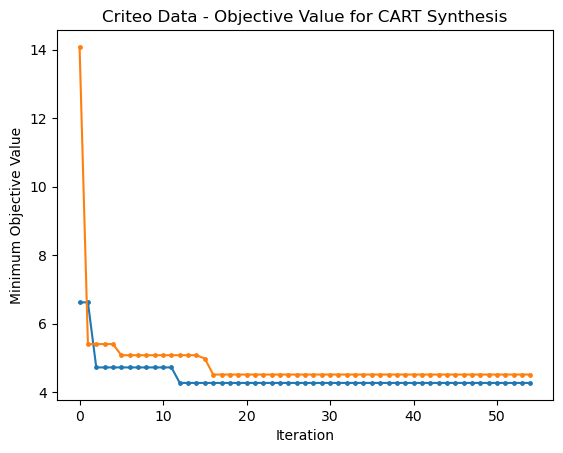

In [18]:
fig = plt.figure()
plt.plot(run_targets[0])
plt.scatter(np.arange(len(run_targets[0])), run_targets[0], s=6)
plt.plot(run_targets[1])
plt.scatter(np.arange(len(run_targets[1])), run_targets[1], s=6)
plt.title("Criteo Data - Objective Value for CART Synthesis")
plt.xlabel("Iteration")
plt.ylabel("Minimum Objective Value")
plt.show()

In [19]:
optimization_results

[{'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples_leaf': np.float64(7315.564803859539)},
    'f9': {'min_samples_leaf': np.float64(5.0)},
    'f3': {'min_samples_leaf': np.float64(5.0)},
    'f4': {'min_samples_leaf': np.float64(11849.090267511412)},
    'f6': {'min_samples_leaf': np.float64(15879.66342302954)},
    'f5': {'min_samples_leaf': np.float64(28494.30607107327)},
    'f11': {'min_samples_leaf': np.float64(18224.146263029463)},
    'f1': {'min_samples_leaf': np.float64(23160.85720708727)},
    'f10': {'min_samples_leaf': np.float64(4718.551458694339)},
    'f0': {'min_samples_leaf': np.float64(18964.20106946018)},
    'f7': {'min_samples_leaf': np.float64(5.0)},
    'f2': {'min_samples_leaf': np.float64(23707.51653000456)}}},
  'best_score': np.float64(4.265034894334589),
  'optimizer': <bayes_opt.bayesian_optimization.BayesianOptimization at 0x22abf9296a0>},
 {'best_params': {'gmm': {},
   'multinomial': {},
   'tree': {'f8': {'min_samples_le

In [20]:
best_params = optimization_results[np.argmin([x['best_score'] for x in optimization_results])]['best_params']

In [21]:
best_state = random_states[np.argmin([x['best_score'] for x in optimization_results])]

In [22]:
# warnings.filterwarnings('ignore')

# again, we are silencing harmless overflow warnings from numpy related to the Yeo-johnson transformation

sds, full_sXs = perform_synthesis_with_param_target(
    train_data=train_data,
    number_synthetic_datasets=20,
    synthesis_steps=synthesis_steps,
    target_params=target_params,
    target_variable=target_variable,
    exog_variables=exog_variables,
    target_uplift_distribution=None,
    param_values=best_params,
    random_state=best_state
)

In [23]:
np.mean(sds)

np.float64(7.070783683951535)

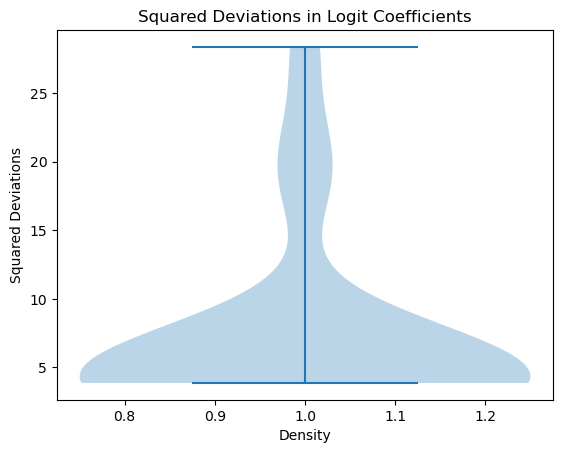

In [24]:
plt.violinplot(sds)
plt.xlabel("Density")
plt.ylabel("Squared Deviations")
plt.title("Squared Deviations in Logit Coefficients")
plt.show()

In [25]:
synthetic_data_path = "../../Data/Criteo/"

for i, sX in enumerate(full_sXs):
    if not os.path.exists(synthetic_data_path):
        os.makedirs(synthetic_data_path)
    sX.to_csv(synthetic_data_path + "cart_" + str(i) + "_" + data_set + "_high_iterations.csv", index=False)

End of file.